In [49]:
!python --version

Python 3.13.11


The system cannot find the path specified.


In [4]:
import os
import io
import json
import base64
from PIL import Image

import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from numpy.typing import NDArray
from matplotlib.axes import Axes
from skimage.draw import polygon2mask
from pycocotools import mask

In [5]:
def plot_binary_mask(ax: Axes, bmask: NDArray[np.integer], height: int, width: int, alpha: float = 0.35, borders: bool = True) -> Axes:
    assert bmask.shape[0] == height and bmask.shape[1] == width, "dimensions of the bmask do not match the params height and width"
    rgba = np.ones((height, width, 4))
    rgba[:, :, 3] = 0  # set all the alpha channel values to 0
    rgba[bmask.astype(np.bool), :] = np.array([*np.random.random(3), alpha])
    ax.imshow(rgba)
    if borders:
        contours, _ = cv2.findContours(bmask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)  # type: ignore
        contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours]  # type: ignore
        cv2.drawContours(image=rgba, contours=contours, contourIdx=-1, color=(0, 0, 1, alpha), thickness=1)

    return ax

In [6]:
# REFERENCES
# https://www.labellerr.com/blog/fine-tune-sam-on-custom-dataset/
# https://encord.com/blog/learn-how-to-fine-tune-the-segment-anything-model-sam/

In [7]:
with open(r"../images/MaxSee/2025_10_08_11_37_58_002.json", mode="rt") as fp:
    ann = json.load(fp)

In [8]:
ann.keys() # looks like the JSON files serialized by labelme also embeds the image TF???

dict_keys(['version', 'flags', 'shapes', 'imagePath', 'imageData', 'imageHeight', 'imageWidth'])

In [9]:
# shapes key contains the polygonal annotations
ann["shapes"]

[{'label': 'root',
  'points': [[248.51063829787222, 960.0000000000001],
   [284.68085106382955, 923.8297872340427],
   [333.61702127659555, 894.0425531914894],
   [376.17021276595733, 872.7659574468086],
   [401.7021276595742, 849.3617021276597],
   [435.74468085106355, 823.8297872340427],
   [471.9148936170211, 787.6595744680852],
   [499.5744680851062, 751.4893617021278],
   [529.3617021276593, 725.9574468085107],
   [569.7872340425529, 694.0425531914894],
   [593.191489361702, 662.1276595744681],
   [616.5957446808509, 634.4680851063831],
   [648.5106382978722, 589.7872340425532],
   [674.0425531914891, 560.0000000000001],
   [682.5531914893616, 534.4680851063831],
   [714.4680851063827, 504.6808510638299],
   [718.7234042553189, 474.89361702127667],
   [731.4893617021273, 442.9787234042554],
   [748.510638297872, 402.5531914893618],
   [757.0212765957444, 383.40425531914906],
   [776.1702127659571, 353.61702127659584],
   [797.446808510638, 319.5744680851065],
   [816.595744680850

In [29]:
# see how this is different from the SA-1B annotations

with open(r"../../notebooks/chapter_01/SA1B/sa_1822.json", mode="rt") as fp:
    sa1b = json.load(fp)

In [31]:
sa1b.keys()

dict_keys(['image', 'annotations'])

In [32]:
sa1b["image"]

{'image_id': 1822, 'width': 1500, 'height': 1875, 'file_name': 'sa_1822.jpg'}

In [36]:
sa1b["annotations"][0]

{'bbox': [694.0, 1379.0, 77.0, 128.0],
 'area': 9653,
 'segmentation': {'size': [1875, 1500],
  'counts': 'jShW1^1dh1P1kWNcMEa0jf1W3K3N1N10001O000000000000000000O1000000000000000O100000000001O0000000001O000000001O000000000000000000000000000000000000000001O000000000000001O0O2O1N5KX3fLhacY1'},
 'predicted_iou': 0.8956656455993652,
 'point_coords': [[728.3125, 1421.25]],
 'crop_box': [622.0, 1215.0, 567.0, 660.0],
 'id': 131671281,
 'stability_score': 0.9685015082359314}

In [35]:
sa1b["annotations"][0]["segmentation"]

{'size': [1875, 1500],
 'counts': 'jShW1^1dh1P1kWNcMEa0jf1W3K3N1N10001O000000000000000000O1000000000000000O100000000001O0000000001O000000001O000000000000000000000000000000000000000001O000000000000001O0O2O1N5KX3fLhacY1'}

In [47]:
mask.decode(sa1b["annotations"][0]["segmentation"]) # whoosh

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(1875, 1500), dtype=uint8)

In [19]:
Image.frombytes(data=bytes(ann["imageData"], encoding="ascii"), size=(ann["imageWidth"], ann["imageHeight"]), mode="RGB")

ValueError: not enough image data

In [24]:
Image.open(io.BytesIO(bytes(ann["imageData"], encoding="utf8")))

UnidentifiedImageError: cannot identify image file <_io.BytesIO object at 0x00000276661367A0>

In [25]:
buff = io.BytesIO()
buff.write(ann["imageData"])
Image.open(buff)

TypeError: a bytes-like object is required, not 'str'

In [71]:
# turns out that labelme uses base64 encoding to embedd the binary image data into the annotation files, WHY????
Image.open(io.BytesIO(base64.b64decode(ann["imageData"]))); # there you go.

In [50]:
# the goal here is to convert the humongous JSON files serialized by labelme to the RLE encoded light COCO JSON files
# looks like once we have a binary mask array, we can then RLE encode it using pycocotools
# so the question is, how to create a binary mask from a set of coordinates???

In [10]:
ann["shapes"][0]["points"]

[[248.51063829787222, 960.0000000000001],
 [284.68085106382955, 923.8297872340427],
 [333.61702127659555, 894.0425531914894],
 [376.17021276595733, 872.7659574468086],
 [401.7021276595742, 849.3617021276597],
 [435.74468085106355, 823.8297872340427],
 [471.9148936170211, 787.6595744680852],
 [499.5744680851062, 751.4893617021278],
 [529.3617021276593, 725.9574468085107],
 [569.7872340425529, 694.0425531914894],
 [593.191489361702, 662.1276595744681],
 [616.5957446808509, 634.4680851063831],
 [648.5106382978722, 589.7872340425532],
 [674.0425531914891, 560.0000000000001],
 [682.5531914893616, 534.4680851063831],
 [714.4680851063827, 504.6808510638299],
 [718.7234042553189, 474.89361702127667],
 [731.4893617021273, 442.9787234042554],
 [748.510638297872, 402.5531914893618],
 [757.0212765957444, 383.40425531914906],
 [776.1702127659571, 353.61702127659584],
 [797.446808510638, 319.5744680851065],
 [816.5957446808509, 296.17021276595756],
 [835.7446808510635, 260.0000000000001],
 [852.7659

In [11]:
# an array of coordinates to a binary mask
_mask = polygon2mask(image_shape=(ann["imageHeight"], ann["imageWidth"]), polygon=ann["shapes"][0]["points"]).astype(np.uint8) # we imported a module named mask from pycocotools, hence the _ prefix
_mask

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(1920, 1080), dtype=uint8)

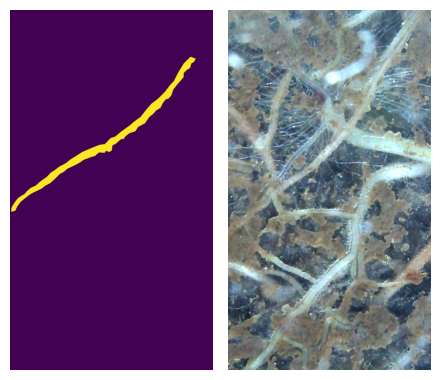

In [13]:
fig, axes = plt.subplots(ncols=2)
fig.set_size_inches(4.5, 4)
axes[0].set_axis_off()
axes[0].imshow(_mask)
axes[1].set_axis_off()
axes[1].imshow(Image.open(r"../images/MaxSee/2025_10_08_11_37_58_002.png")) # COOL :)
plt.tight_layout()
plt.show()

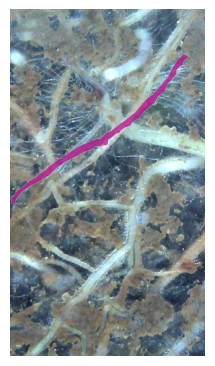

In [16]:
# try overlaying the annotation over the actual image
fig, axes = plt.subplots()
fig.set_size_inches(2.25, 4)
axes.set_axis_off()
axes.imshow(Image.open(r"../images/MaxSee/2025_10_08_11_37_58_002.png")) 
plot_binary_mask(ax=axes, bmask=_mask, height=1920, width=1080, alpha=0.8) # TF???
plt.tight_layout()
plt.show()

In [20]:
# are we using the same image
ann["imagePath"] # what's happening here???

'2025_10_08_11_37_58_002.png'